# Per-sample sqrt-PEHE stratified by overlap score, across the four overlap regimes

For each synthetic config we (i) sample once with `seed=42`, (ii) train every
learner on the train split, (iii) record per-sample
`|tau_hat(x) - tau(x)|` on the test split, (iv) bin test samples by the
overlap score `omega = rho(X) * pi(X) * (1 - pi(X))` into 5 quantile bins,
and (v) draw the per-(learner, bin) boxplot. Plots use `text.usetex=True`.

Datasets (single run, NN backbone):
- `syn-low-treatment-overlap`  $\mathcal{D}_{t}$
- `syn-low-outcome-overlap`    $\mathcal{D}_{o}$
- `syn-dual-overlap`           $\mathcal{D}_{t+o}$
- `syn-healthy`                $\mathcal{D}_{*}$

In [1]:
import os, sys, warnings, logging
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)  # load_config reads relative 'config/config.yaml'

warnings.filterwarnings('ignore')
logging.getLogger('sklearn').setLevel(logging.ERROR)

from src.data.synthetic import NieWagerSyntheticDataset
from src.data.utils import load_config, split_two_sample_data
from src.eval_utils import (
    DEFAULT_MODELS_NN, LEARNER_REGISTRY,
    seed_model_cfg, swap_cate_regressor_to_nn,
)

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 16,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14,
})

OUT_DIR = ROOT / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODELS = list(DEFAULT_MODELS_NN)
EXCLUDE = {'TO-learner', 'DO-learner'}
LABEL_MAP = {
    'TO-learner-2': 'LT-O-TO-learner',
    'DO-learner-2': 'LT-O-DO-learner',
}

_GREEN_LEVELS  = {"LO-learner": 0.55, "TO-learner-2": 0.78, "DO-learner-2": 1.00}
_GREEN_MARKERS = {"LO-learner": "P",  "TO-learner-2": "v",  "DO-learner-2": "s"}
_greens = mpl.colormaps["Greens"]
_lto_styles = {m: dict(marker=_GREEN_MARKERS[m], color=_greens(lvl))
               for m, lvl in _GREEN_LEVELS.items()}
STYLE = {
    "T-learner":    dict(marker="o", color="blue"),
    "RA-learner":   dict(marker="x", color="purple"),
    "IPW-learner":  dict(marker="d", color="red"),
    "DR-learner":   dict(marker="^", color="orange"),
    **_lto_styles,
}


def run_overlap_strat(dataset, dataset_tex, save_name=None,
                       seed=42, n_bins=5, test_fraction=0.2):
    base_cfg = load_config(dataset=dataset, model=MODELS[0], trainer='default')
    ds_cfg = deepcopy(base_cfg.dataset)
    OmegaConf.set_struct(ds_cfg, False)
    ds_cfg.seed = seed
    ds = NieWagerSyntheticDataset(ds_cfg)
    data, gt = ds.sample()
    train, _, test = split_two_sample_data(
        data, val_fraction=0.0, test_fraction=test_fraction, random_state=seed,
    )
    tau_true = gt.tau(test.X_e)
    print(f'{dataset}  gamma_pi={ds_cfg.gamma}  gamma_rho={ds_cfg.gamma_rho}  '
          f'n={ds_cfg.n}  test.X_e={test.X_e.shape[0]}')

    abs_err = {}
    for m in MODELS:
        cfg_m = load_config(dataset=dataset, model=m, trainer='default').model
        cfg_m = swap_cate_regressor_to_nn(cfg_m)
        cfg_m = seed_model_cfg(cfg_m, seed=seed)
        learner = LEARNER_REGISTRY[m](cfg_m)
        learner.fit(train)
        abs_err[m] = np.abs(learner.predict_cate(test.X_e) - tau_true)

    rho   = ds.rho_x(test.X_e)
    pi    = ds.pi_E(test.X_e)
    omega = rho * pi * (1.0 - pi)
    edges = np.quantile(omega, np.linspace(0, 1, n_bins + 1))
    edges[0] -= 1e-12; edges[-1] += 1e-12
    bin_idx = np.clip(np.digitize(omega, edges) - 1, 0, n_bins - 1)
    bin_labels = [rf'$B_{{{i+1}}}$' for i in range(n_bins)]

    models_plot = [m for m in STYLE if m in abs_err and m not in EXCLUDE]
    labels_plot = [LABEL_MAP.get(m, m) for m in models_plot]
    n_models = len(models_plot)
    width = 0.8 / n_models

    fig, ax = plt.subplots(figsize=(max(11, 1.8 * n_bins * n_models / 4), 6))
    for j, (m, lab) in enumerate(zip(models_plot, labels_plot)):
        err = abs_err[m]
        data_per_bin = [err[bin_idx == i] for i in range(n_bins)]
        positions = np.arange(n_bins) + (j - (n_models - 1) / 2) * width
        color  = STYLE[m]['color']
        marker = STYLE[m]['marker']
        bp = ax.boxplot(
            data_per_bin, positions=positions, widths=width * 0.9,
            patch_artist=True, showfliers=False, showmeans=True,
            medianprops=dict(color='black', linewidth=1.0),
            meanprops=dict(marker=marker, markerfacecolor=color,
                           markeredgecolor='black', markersize=8),
        )
        for box in bp['boxes']:
            box.set_facecolor(color); box.set_alpha(0.75); box.set_edgecolor('black')
        bp['boxes'][0].set_label(lab)

    ax.set_xticks(np.arange(n_bins))
    ax.set_xticklabels(bin_labels)
    ax.set_xlabel(r'overlap score $\omega = \rho(X)\,\pi(X)\,(1-\pi(X))$ (quantile bins)')
    ax.set_ylabel(r'$|\hat{\tau}(x) - \tau(x)|$')
    ax.set_title(rf'{dataset_tex}: per-sample $\sqrt{{\mathrm{{PEHE}}}}$ vs.\ overlap-score bin')
    ax.legend(loc='upper right', ncol=2)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    if save_name is not None:
        path = OUT_DIR / f'syn_overlap_strat_{save_name}.pdf'
        fig.savefig(path, bbox_inches='tight')
        #print(f'  -> saved {path}')
    plt.show()

    rows = []
    for m in models_plot:
        err = abs_err[m]
        row = {'model': LABEL_MAP.get(m, m)}
        for i in range(n_bins):
            row[f'B{i+1}_median'] = float(np.median(err[bin_idx == i]))
        row['overall_PEHE'] = float(np.mean(err ** 2))
        rows.append(row)
    return pd.DataFrame(rows).sort_values('overall_PEHE').reset_index(drop=True)

syn-low-treatment-overlap  gamma_pi=5.0  gamma_rho=0.0  n=10000  test.X_e=990


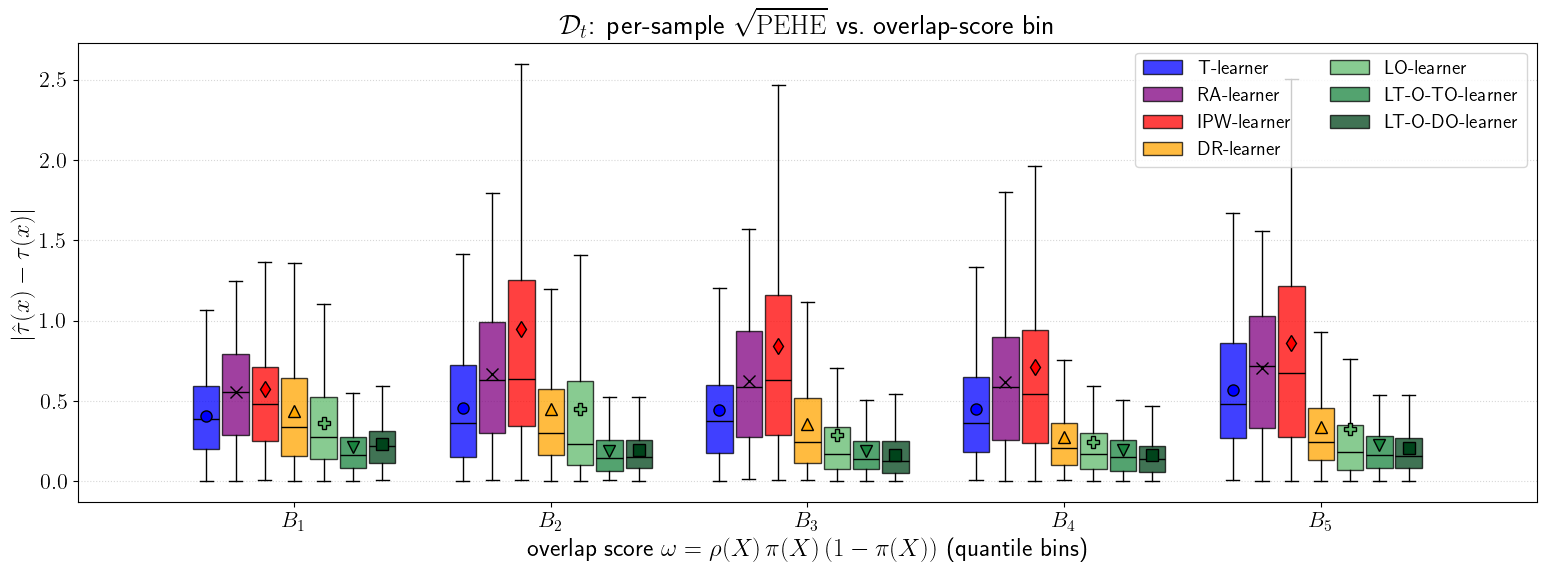

,model,B1_median,B2_median,B3_median,B4_median,B5_median,overall_PEHE
0,LT-O-DO-learner,0.222140,0.154369,0.128360,0.139424,0.160572,0.061145
1,LT-O-TO-learner,0.165681,0.146272,0.138697,0.148305,0.166344,0.077896
2,DR-learner,0.339656,0.300264,0.243891,0.210236,0.246826,0.251250
3,LO-learner,0.276683,0.231982,0.171767,0.172302,0.181168,0.294040
4,T-learner,0.388787,0.362334,0.374531,0.363385,0.478184,0.336326
5,RA-learner,0.556702,0.628088,0.589661,0.587689,0.717191,0.563538
6,IPW-learner,0.480929,0.635918,0.628896,0.546243,0.676175,1.164140


In [3]:
df_t = run_overlap_strat(
    'syn-low-treatment-overlap', r'$\mathcal{D}_{t}$',
    save_name='low_treatment',
)
df_t

syn-low-outcome-overlap  gamma_pi=0.0  gamma_rho=4.0  n=10000  test.X_e=1949


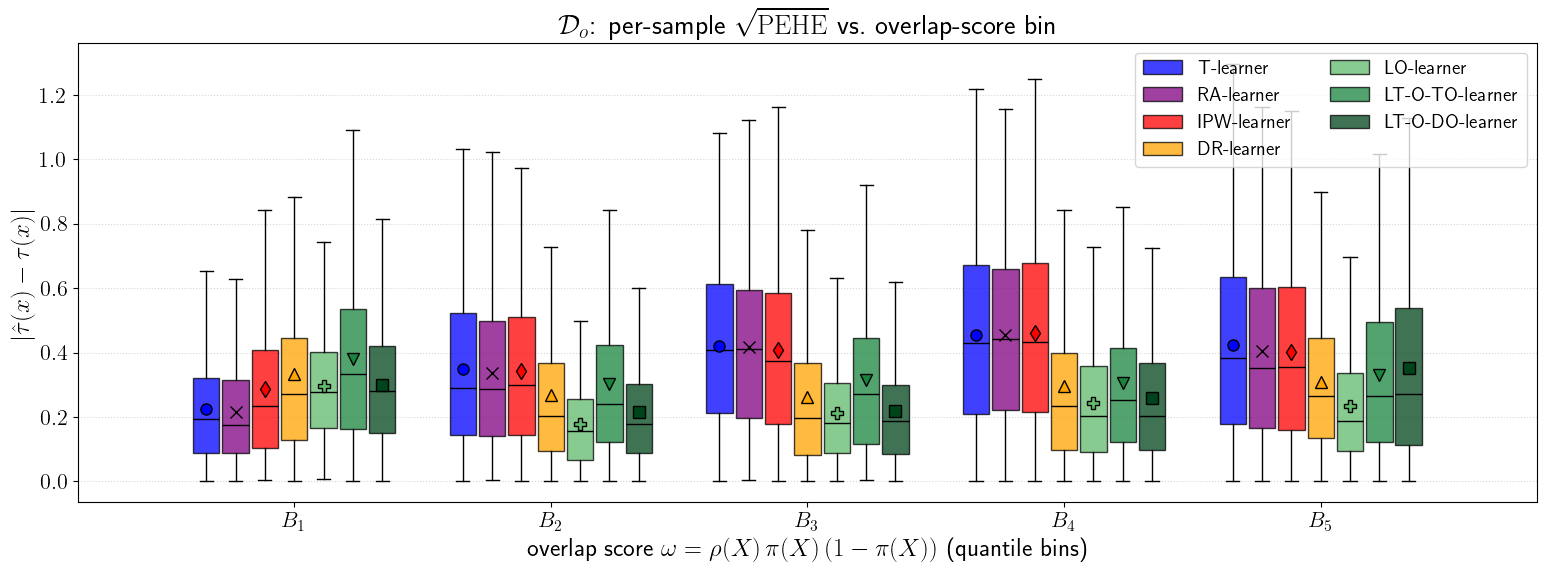

,model,B1_median,B2_median,B3_median,B4_median,B5_median,overall_PEHE
0,LO-learner,0.277271,0.156719,0.181808,0.203860,0.187871,0.083994
1,LT-O-DO-learner,0.279016,0.178035,0.187237,0.203019,0.271143,0.120010
2,DR-learner,0.272715,0.202386,0.197333,0.232552,0.264431,0.151874
3,LT-O-TO-learner,0.334863,0.241544,0.270320,0.251483,0.264787,0.173275
4,RA-learner,0.173819,0.286855,0.410060,0.440555,0.353029,0.204202
5,T-learner,0.193413,0.290411,0.408499,0.429209,0.382462,0.213439
6,IPW-learner,0.232518,0.299955,0.375294,0.432935,0.353972,0.219561


In [4]:
df_o = run_overlap_strat(
    'syn-low-outcome-overlap', r'$\mathcal{D}_{o}$',
    save_name='low_outcome',
)
df_o

syn-dual-overlap  gamma_pi=5.0  gamma_rho=3.0  n=10000  test.X_e=1871


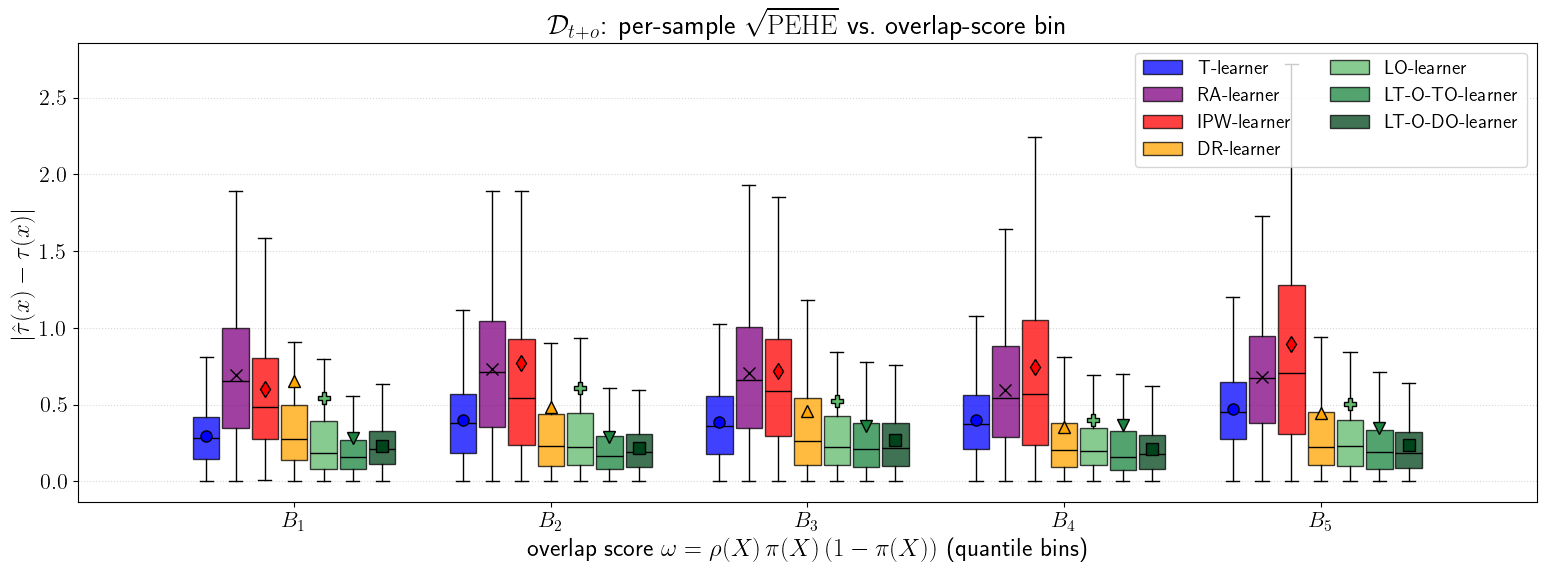

,model,B1_median,B2_median,B3_median,B4_median,B5_median,overall_PEHE
0,LT-O-DO-learner,0.213093,0.190471,0.217723,0.179961,0.181558,0.090707
1,T-learner,0.285015,0.377685,0.358732,0.370385,0.449470,0.213095
2,LT-O-TO-learner,0.155657,0.161976,0.208756,0.156268,0.188713,0.392592
3,RA-learner,0.655236,0.715417,0.663167,0.540006,0.674758,0.639410
4,DR-learner,0.277930,0.228979,0.261257,0.202265,0.225498,0.859653
5,IPW-learner,0.483313,0.540113,0.590503,0.568296,0.703591,1.013638
6,LO-learner,0.187224,0.222341,0.225482,0.199594,0.230324,1.123832


In [5]:
df_to = run_overlap_strat(
    'syn-dual-overlap', r'$\mathcal{D}_{t+o}$',
    save_name='dual',
)
df_to

syn-healthy  gamma_pi=0.0  gamma_rho=0.0  n=10000  test.X_e=990


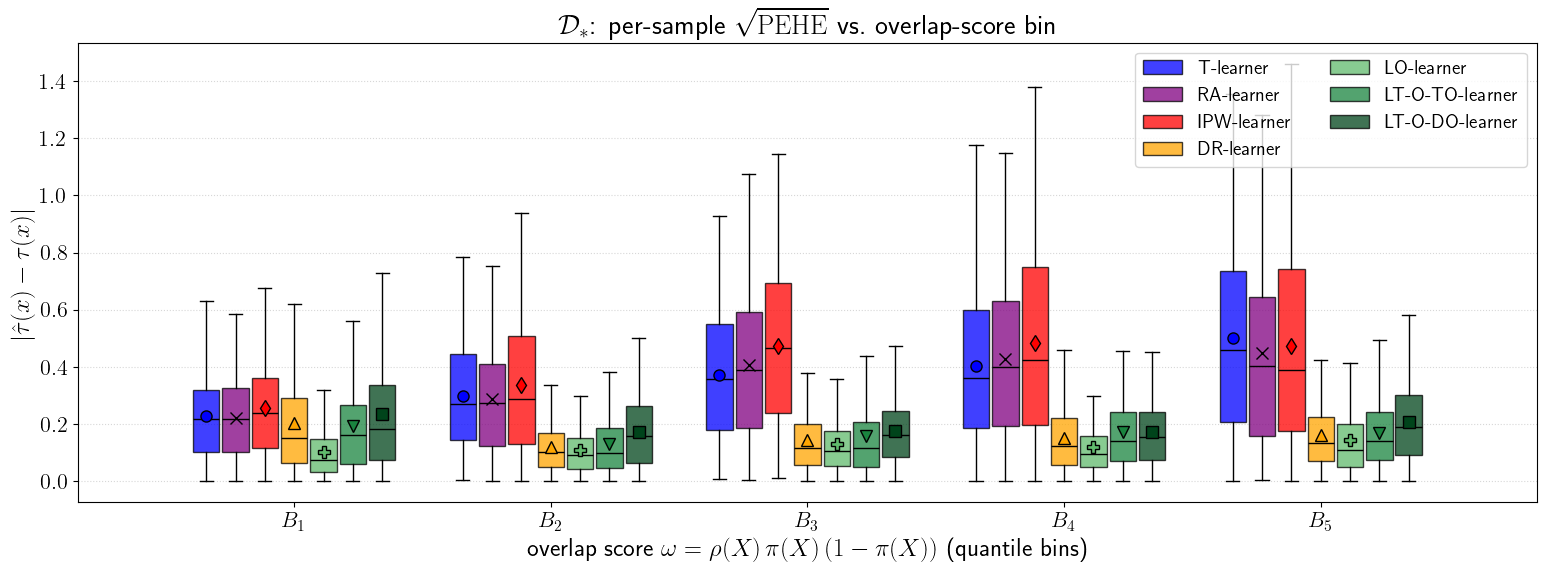

,model,B1_median,B2_median,B3_median,B4_median,B5_median,overall_PEHE
0,LO-learner,0.075517,0.091819,0.105595,0.095286,0.110671,0.025447
1,DR-learner,0.150385,0.103366,0.114905,0.123257,0.135533,0.042568
2,LT-O-TO-learner,0.160589,0.099329,0.117036,0.139819,0.141296,0.048829
3,LT-O-DO-learner,0.181763,0.158428,0.160427,0.153408,0.189567,0.059310
4,T-learner,0.217038,0.271226,0.357751,0.361358,0.460787,0.197478
5,RA-learner,0.217137,0.272296,0.389494,0.400341,0.401717,0.198003
6,IPW-learner,0.238343,0.287257,0.466062,0.425648,0.390305,0.251832


In [6]:
df_h = run_overlap_strat(
    'syn-healthy', r'$\mathcal{D}_{*}$',
    save_name='healthy',
)
df_h